# Epidemic Simulation Exploration

This notebook demonstrates the use of the `epi_structure` simulation engine with synthetic data.

## Pedagogical Hypothesis Scaffold

This notebook demonstrates model mechanics for learning and discussion.
It is not a direct claim about any specific real-world outbreak.

### Hypothesis Being Illustrated
- Under a stated parameter set, this compartment model produces the plotted trajectory.

### Assumptions in This Run
- Inputs are synthetic and deterministic.
- Parameter choices are explicit and editable.

### What Would Falsify This Specific Story
- Small, relevant parameter changes produce qualitatively different outcomes.
- A different mechanism explains the same pattern with fewer assumptions.

### Scope Reminder
- Use this notebook to sharpen intuition and generate testable follow-up questions.
- Treat outputs as conditional on assumptions, not standalone evidence.

In [1]:
# Initialize Notebook Environment
import sys
from pathlib import Path

# Add project root to Python path for imports
project_root = Path("../..")
sys.path.insert(0, str(project_root))

from epi_structure import DiseaseParameters, EpidemicModel, PopulationParameters, SimulationParameters

In [2]:
# Generate Fake Input Data
import random

random.seed(42)  # Ensure reproducibility

population = PopulationParameters(
    name="synthetic-pop",
    size=1000,
    beta=0.0003,
    disease=DiseaseParameters(infectious_period=7.0, latent_period=3.0, waning_period=120.0),
)
simulation = SimulationParameters(time_step=0.1, duration=30.0, output_stride=10)

In [3]:
# Instantiate and Configure the Engine
model = EpidemicModel(population, simulation)
print("Model initialized with:")
print(f"Population: {population}")
print(f"Simulation: {simulation}")

Model initialized with:
Population: PopulationParameters(name='synthetic-pop', size=1000, beta=0.0003, initial_susceptible=999, initial_exposed=0, initial_infected=1, initial_recovered=0, disease=DiseaseParameters(infectious_period=7.0, latent_period=3.0, waning_period=120.0))
Simulation: SimulationParameters(time_step=0.1, duration=30.0, output_stride=10)


In [4]:
# Run the Engine with Synthetic Data
trajectory = model.simulate()
print(f"Simulation produced {len(trajectory)} state points.")

Simulation produced 31 state points.


Matplotlib is building the font cache; this may take a moment.


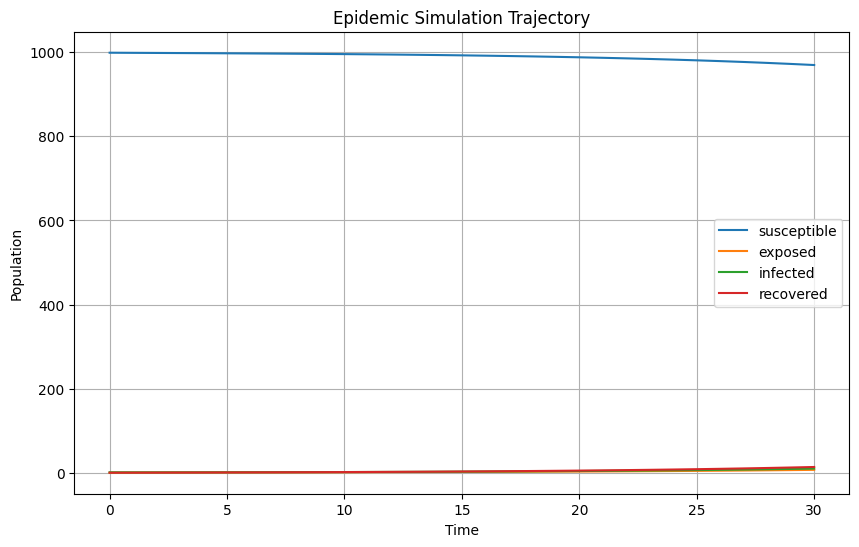

In [5]:
# Inspect and Visualize Results
import pandas as pd
import matplotlib.pyplot as plt

# Convert trajectory to DataFrame
data = pd.DataFrame(
    {
        "time": [point.time for point in trajectory],
        "susceptible": [point.susceptible for point in trajectory],
        "exposed": [point.exposed for point in trajectory],
        "infected": [point.infected for point in trajectory],
        "recovered": [point.recovered for point in trajectory],
    }
)

# Plot results
plt.figure(figsize=(10, 6))
for column in ["susceptible", "exposed", "infected", "recovered"]:
    plt.plot(data["time"], data[column], label=column)

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Epidemic Simulation Trajectory")
plt.legend()
plt.grid()
plt.show()

In [6]:
# Add Lightweight Assertions for Exploration
assert len(trajectory) > 0, "Trajectory should not be empty."
assert trajectory[0].total_population == trajectory[-1].total_population, "Population should be conserved."
print("Assertions passed.")

Assertions passed.
